In [48]:
from langgraph.graph import StateGraph ,START,END
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from typing import TypedDict , Literal
from pydantic import BaseModel , Field
from dotenv import load_dotenv


In [49]:
load_dotenv()

True

In [50]:
model = ChatNVIDIA(model='nvidia/nemotron-3-super-120b-a12b')

In [51]:
class DeliveryState(TypedDict):

    query : str
    query_classifer : Literal['refund','technical','general']
    response : str


In [52]:
class ClassfierSchema(BaseModel):
    query : str
    query_classifer : Literal['refund','technical','general'] = Field(description='classification of the query')

In [53]:
structure_model = model.with_structured_output(ClassfierSchema)

In [54]:
def query_classifer(state:DeliveryState):

    prompt = f"classify the given query \n -{state['query']}"
    query_classifer = structure_model.invoke(prompt).query_classifer

    return {'query_classifer':query_classifer}


def refund_issue(state:DeliveryState):
    prompt = f"write an apologize response and a solution for the following query - {state['query']}"

    response = model.invoke(prompt).content

    return {'response':response}


def technical_issue(state:DeliveryState):
    prompt = f"write an solution for this technical query and make and apoloigze for the follwing query - \n {state['query']}"
    response = model.invoke(prompt)

    return {'response':response}


def general_issue(state:DeliveryState):
    prompt = f"write an solution for this general issue from the following query \n {state['query']}"
    response = model.invoke(prompt)

    return {'response':response}


def check_condition(state:DeliveryState) -> Literal['refund_issue','technical_issue','general_issue']:
    if state['query_classifer'] == 'refund':
        return 'refund_issue'
    elif state['query_classifer'] == 'technical':
        return 'technical_issue'
    else:
        return 'general_issue'


In [55]:
graph = StateGraph(DeliveryState)

graph.add_node('query_classifer',query_classifer)


graph.add_node('refund_issue',refund_issue)
graph.add_node('technical_issue',technical_issue)
graph.add_node('general_issue',general_issue)


graph.add_edge(START,'query_classifer')
graph.add_conditional_edges('query_classifer',check_condition)

graph.add_edge('refund_issue',END)
graph.add_edge('technical_issue',END)
graph.add_edge('general_issue',END)


workflow = graph.compile()

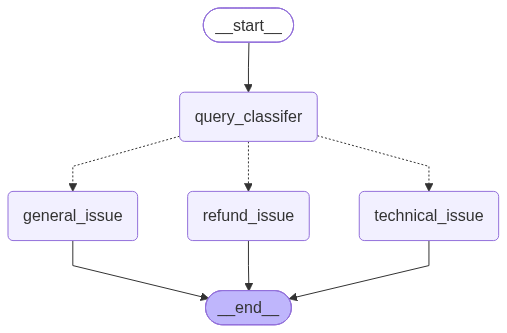

In [56]:
workflow

In [57]:
inital_workflow = {
    'query':"My order arrived damaged and I want a refund."
}

workflow.invoke(inital_workflow)

{'query': 'My order arrived damaged and I want a refund.',
 'query_classifer': 'refund',
 'response': 'Here’s a sincere, solution-focused response that validates the customer’s frustration, takes ownership, and provides a clear, easy path to resolution—designed to rebuild trust and turn a negative experience into a positive one:\n\n---\n\n**Subject:** Sincere Apology & Immediate Resolution for Your Damaged Order #[Order Number]  \n\nDear [Customer Name],  \n\nThank you for reaching out—I’m truly sorry your order arrived damaged. This is absolutely not the experience we strive to provide, and I understand how frustrating and disappointing this must be, especially when you were excited to receive your purchase. Please know we take full responsibility for this, and we’re committed to making it right for you **right away**.  \n\n### Here’s how we’ll resolve this immediately:  \n1. **Instant Refund or Replacement** (your choice):  \n   - ✅ **Option 1: Full Refund** – Processed to your origi

{'query': 'My order arrived damaged and I want a refund.',
 'query_classifer': 'refund',
 'response': 'Here’s a sincere, solution-focused response that validates the customer’s frustration, takes ownership, and provides a clear, easy path to resolution—designed to rebuild trust and turn a negative experience into a positive one:\n\n---\n\n**Subject:** Sincere Apology & Immediate Resolution for Your Damaged Order #[Order Number]  \n\nDear [Customer Name],  \n\nThank you for reaching out—I’m truly sorry your order arrived damaged. This is absolutely not the experience we strive to provide, and I understand how frustrating and disappointing this must be, especially when you were excited to receive your purchase. Please know we take full responsibility for this, and we’re committed to making it right for you **right away**.  \n\n### Here’s how we’ll resolve this immediately:  \n1. **Instant Refund or Replacement** (your choice):  \n   - ✅ **Option 1: Full Refund** – Processed to your original payment method within **2 business hours** (you’ll receive a confirmation email shortly).  \n   - ✅ **Option 2: Free Replacement** – We’ll expedite a brand-new item to you **today** with **free express shipping** (no return of the damaged item needed—we’ll handle disposal/recycling responsibly).  \n   *Just reply to this email with “REFUND” or “REPLACEMENT,” and we’ll action it immediately.*  \n\n2. **Our Apology Gift**:  \n   As a token of our sincere regret for the inconvenience, please enjoy **15% off your next order** with us (code: **WECARE15**, valid for 30 days). We hope this helps restore your confidence in us.  \n\n### To help us prevent this in the future:  \nIf you’re comfortable, could you please reply with a quick photo of the damaged item and packaging? This helps us investigate with our shipping team and improve our quality checks—**but only if it’s easy for you**. No pressure at all; your resolution is our priority either way.  \n\nAgain, I’m deeply sorry this happened. You deserve better, and we’re grateful you gave us the chance to fix this. If you have any other questions or need further assistance, please don’t hesitate to reply directly to this email—I’m here to help personally.  \n\nWarm regards,  \n[Your Full Name]  \n[Your Job Title]  \n[Company Name] Customer Care Team  \n[Phone Number] | [Email Address]  \n\n---\n\n### Why this response works:  \n- **Empathy First**: Opens with a specific, heartfelt apology (not generic “we apologize for any inconvenience”) and validates their emotions.  \n- **'}